*This notebook is not important*
___
# Testing

In [25]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from utils import factor_model_solution

In [11]:
df_gene_effect = pd.read_csv("Xavier_DataAnalysis/preprocessed_data/20Q4v2_Achilles_gene_effect.csv")

df_gene_effect.head()

,DepMap_ID,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)
0,ACH-000004,0.181332,0.089101,-0.193867,-0.024587,0.038458,-0.181824,0.351672,-0.440073,0.292582,...,-0.124218,-0.469306,NaN,NaN,0.257361,0.244834,-0.408512,0.284734,0.226412,-0.149566
1,ACH-000005,-0.076383,0.245190,0.191238,0.153008,-0.197035,-0.323295,0.252522,-0.571498,-0.068945,...,-0.212442,-0.426151,-0.068295,0.031635,0.205469,-0.068536,-0.092858,0.074640,0.028779,-0.264840
2,ACH-000007,0.102195,0.092449,-0.045926,0.171892,0.140561,0.170971,0.086060,-0.432320,0.010664,...,-0.083183,-0.269196,0.101146,0.277820,0.208814,0.001393,-0.327514,0.048714,-0.372854,-0.433157
3,ACH-000009,0.142342,-0.033126,-0.051224,0.060560,0.116002,-0.010044,0.104725,-0.610481,0.181508,...,-0.277264,-0.307018,0.044741,0.201551,0.083866,0.052208,-0.574719,0.218682,-0.074750,-0.551760
4,ACH-000011,0.280082,0.088898,0.032321,0.446598,-0.037188,-0.228207,0.110942,-0.406541,0.153979,...,-0.385241,-0.476314,-0.000984,0.013225,0.294002,0.137939,-0.245951,0.111173,-0.227417,-0.349564


In [24]:
df_gene_effect.iloc[:, 1:2000].dropna()

,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),AADAC (13),...,C8orf88 (100127983),C9 (735),C9orf116 (138162),C9orf129 (445577),C9orf131 (138724),C9orf135 (138255),C9orf152 (401546),C9orf153 (389766),C9orf16 (79095),C9orf24 (84688)
1,-0.076383,0.245190,0.191238,0.153008,-0.197035,-0.323295,0.252522,-0.571498,-0.068945,0.011962,...,-0.296019,-0.349246,0.098365,-0.253266,0.027539,0.043954,-0.056718,0.037825,-0.331921,-0.270486
2,0.102195,0.092449,-0.045926,0.171892,0.140561,0.170971,0.086060,-0.432320,0.010664,0.305225,...,-0.191010,-0.171280,0.005401,-0.122555,-0.083956,0.023247,0.052596,0.330079,-0.273909,-0.238234
3,0.142342,-0.033126,-0.051224,0.060560,0.116002,-0.010044,0.104725,-0.610481,0.181508,0.096782,...,-0.144196,0.044435,-0.404099,-0.118583,-0.315424,0.073907,0.132558,0.106506,-0.554836,-0.283868
4,0.280082,0.088898,0.032321,0.446598,-0.037188,-0.228207,0.110942,-0.406541,0.153979,0.109069,...,-0.199281,-0.076655,-0.094162,-0.236288,0.104332,0.139633,0.150072,0.032757,-0.490108,-0.225509
5,0.033135,0.170999,0.098445,0.298867,0.063956,-0.178656,0.328967,-0.472714,0.091884,0.341849,...,-0.224900,-0.042597,-0.328503,-0.300333,-0.050071,0.047156,0.043701,0.021143,-0.407370,-0.088555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
803,0.089323,0.221989,-0.083469,0.031562,-0.042441,-0.065885,0.143498,-0.728552,0.082886,0.068967,...,-0.232405,-0.177712,-0.242415,-0.359209,-0.056957,0.193282,-0.086618,-0.040136,-0.395061,-0.250847
804,-0.019394,0.208518,-0.023968,0.216637,-0.186936,-0.141624,0.060563,-0.258806,0.083777,-0.016547,...,-0.205315,-0.069188,-0.011855,-0.252619,-0.138351,0.056660,0.044945,0.049795,-0.378972,-0.327219
805,-0.061388,0.413876,0.107831,0.143346,-0.152921,-0.097859,0.201287,-0.380150,-0.243889,0.117376,...,-0.158747,-0.029184,0.363774,-0.254873,-0.173303,0.140374,-0.299452,-0.088053,-0.607141,-0.321630
806,0.049819,0.187200,0.037022,0.193399,-0.156752,-0.128821,0.183871,-0.648120,0.054867,0.173556,...,-0.120108,-0.145985,-0.110610,-0.239131,-0.267655,-0.013598,0.040427,0.187374,-0.340126,-0.334430


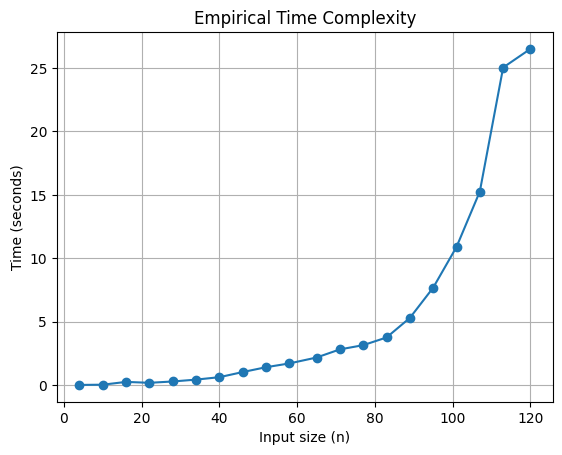

In [48]:
def time_function(func, sizes):
    times = []
    for size in sizes:
        input_data = df_gene_effect.iloc[:, 1:size].dropna()
        start = time.time()
        func(input_data)
        end = time.time()
        times.append(end - start)
    return times

# Define the range of input sizes
input_sizes = np.linspace(4, 120, 20, dtype=int)

# Time the example function
execution_times_FA = time_function(lambda x: factor_model_solution(x, k = 1), input_sizes)
execution_times_corr = time_function(lambda x: np.corrcoef(x.T), input_sizes)

# Plotting
plt.plot(input_sizes, execution_times_FA, marker='o')
plt.xlabel('Input size (n)')
plt.ylabel('Time (seconds)')
plt.title('Empirical Time Complexity')
plt.grid(True)
plt.show()


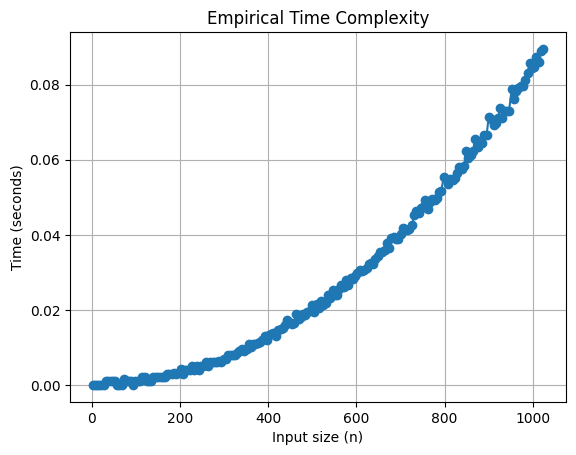

In [ ]:
def corr_func(x):
    corr = np.corrcoef(x.T).flatten()
    return np.sort(corr)

execution_times_corr = time_function(corr_func, input_sizes)

# Plotting
plt.plot(input_sizes, execution_times_corr, marker='o')
plt.xlabel('Input size (n)')
plt.ylabel('Time (seconds)')
plt.title('Empirical Time Complexity')
plt.grid(True)
plt.show()

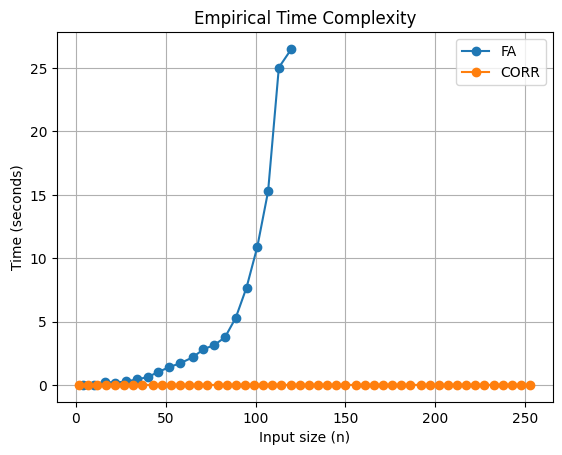

In [54]:
plt.plot(input_sizes, execution_times_FA, label="FA", marker='o')
plt.plot(np.linspace(2, 2**10, 200, dtype=int)[:50], execution_times_corr[:50], label="CORR", marker='o')
plt.legend()
plt.xlabel('Input size (n)')
plt.ylabel('Time (seconds)')
plt.title('Empirical Time Complexity')
plt.grid(True)
plt.show()